In [22]:
options(stringsAsFactors = F)
Sys.setenv(LANGUAGE = "en")

library("ggplot2")
library("scales")
library("RColorBrewer")
library("ggsci")
library("ggpubr")
suppressPackageStartupMessages(library(dplyr))
library('ggprism')
library('patchwork')
suppressPackageStartupMessages(library("tidyverse"))

In [23]:
mytheme<-theme(
legend.title = element_blank(),legend.position = "top", #legend.text = element_text(size = 14,face = "bold",color = "black"),
panel.border = element_rect(color = "black", linewidth = 1.5),  # 加粗边框
panel.grid = element_blank(),axis.title = element_text(size=14),
plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
axis.line=element_line(linewidth=1,colour="black"),
axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
title=element_text(face="bold", colour= "black", size=14),
axis.text.x = element_text(face="bold", color="black", size=14, angle=0),# vjust=0.85, hjust=0.75),
axis.text.y = element_text(face="bold", color="black", size=14),
legend.text = element_text(face="bold", color="black", size=14),
axis.title.x = element_text(face="bold", color="black", size=14),
axis.title.y = element_text(face="bold",color="black", size=14))
mytheme = mytheme+ggplot2::theme(legend.text = element_text(size = 14,face = "bold",color = "black"))

SEM_ebtop<-function(x){
  return(mean(x)+(sd(x)/sqrt(length(x))))
}
SEM_ebbottom<-function(x){
  #return(mean(x)-(sd(x)/sqrt(length(x))))
  return(mean(x))
}

In [57]:
data = readr::read_tsv("/share/hongxiaoning/Project/17.DeepCircle/06.Aln_tools/Merged_Metric.tsv", skip = 0, comment = "#", col_names = TRUE, progress =FALSE, show_col_types = FALSE)
data$Depth = factor(data$Depth, levels=rev(c("50X", "45X", "40X", "35X", "30X", "25X", "20X", "15X", "10X", "5X")))

Warning message in geom_bar(stat = "summary", fun = "mean", colour = "black", size = 1, :
“Ignoring unknown parameters: `size`”


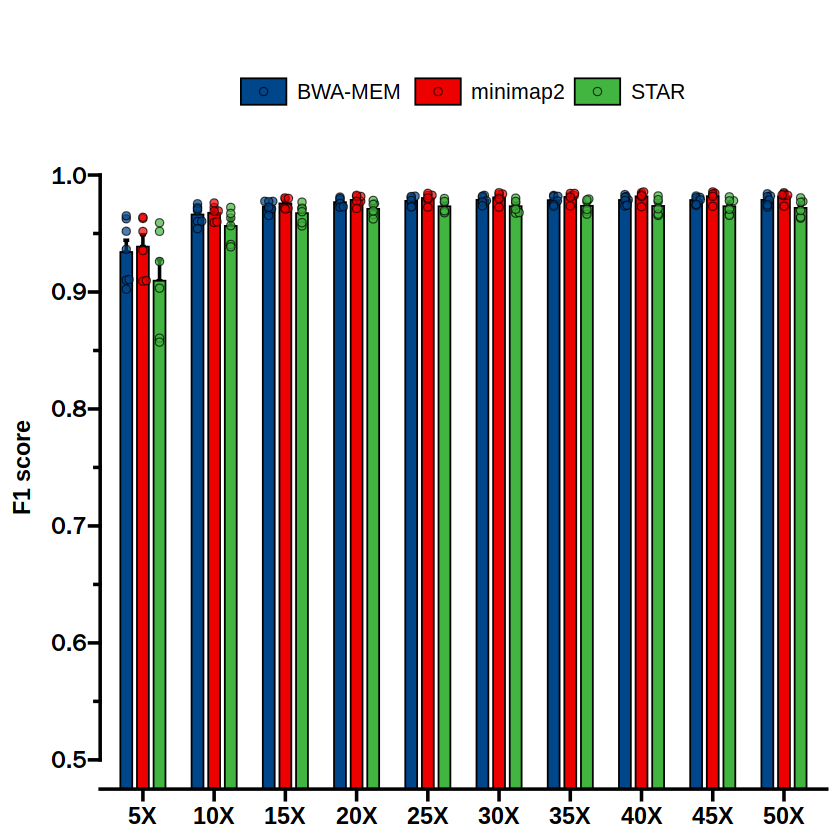

In [58]:
tool_bar = ggplot(data,aes(x=Depth, y=F1score, fill = Tools))+ 
    stat_summary(geom='errorbar',fun.max = SEM_ebtop,fun.min=SEM_ebbottom,colour = "black", size=1, width = 0.25, position = position_dodge( .7)) +
    geom_bar(stat = "summary", fun="mean",colour= "black", size=1, width=0.5, position=position_dodge(.7), alpha=1) +
    ggbeeswarm::geom_beeswarm(
    aes(fill = Tools),
    dodge.width = 0.7,  
    cex = 0.6,  
    size = 2,   
    shape = 21, 
    stroke = 0.5, 
    alpha = 0.7  
  ) +
    scale_fill_lancet() +scale_color_lancet() +
    coord_cartesian(ylim = c(0.5, 1.0)) +
    labs(title = "",
       x = NULL, 
       y = "F1 score") +
   theme_classic()+mytheme+ theme_prism(base_size = 16) +guides(y = "prism_offset_minor") +
   ggplot2::theme(legend.position = "top")
tool_bar

In [24]:
data = readr::read_tsv("Merged_Log.txt", skip = 0, comment = "#", col_names = TRUE, progress =FALSE, show_col_types = FALSE)
data$Tools = factor(data$Tools, levels=c("Deep_eccScan", "Circle_finder", "ecc_finder", "CircleMap", "ECCsplorer"))
data$Depth = factor(data$Depth, levels=rev(c("Real_Sample","50X", "40X", "30X","20X", "10X")))

Warning message in geom_bar(stat = "summary", fun = "mean", colour = "black", size = 1, :
“Ignoring unknown parameters: `size`”


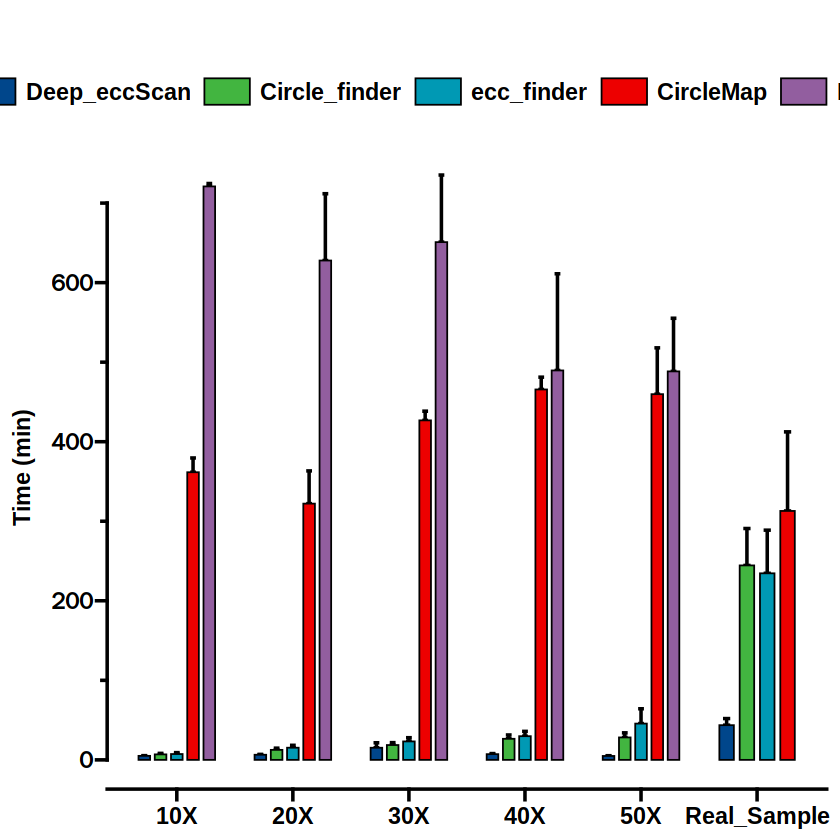

In [145]:
time_bar = ggplot(data,aes(x=Depth, y=Total_minutes, fill = Tools))+ 
    stat_summary(geom='errorbar',fun.max = SEM_ebtop,fun.min=SEM_ebbottom,colour = "black", size=1, width = 0.25, position = position_dodge( .7)) +
    geom_bar(stat = "summary", fun="mean",colour= "black", size=1, width=0.5, position=position_dodge(.7), alpha=1) +
    scale_fill_manual(values=c('Deep_eccScan'='#00468BFF', 'CircleMap'='#ED0000FF', 'Circle_finder'='#42B540FF', 'ecc_finder'='#0099B4FF', 'ECCsplorer'='#925E9FFF')) +
    #scale_color_manual(values=c('Deep_eccScan'='#00468BFF', 'CircleMap'='#ED0000FF', 'Circle_finder'='#42B540FF', 'ecc_finder'='#0099B4FF', 'ECCsplorer'='#925E9FFF')) +
  labs(title = "",
       x = NULL, 
       y = "Time (min)") +
   theme_classic()+mytheme+ theme_prism(base_size = 16) +guides(y = "prism_offset_minor") +
   ggplot2::theme(legend.position = 'top')+ggplot2::theme(legend.text = element_text(size = 14,face = "bold",color = "black"))
time_bar

Warning message in geom_bar(stat = "summary", fun = "mean", colour = "black", size = 1, :
“Ignoring unknown parameters: `size`”


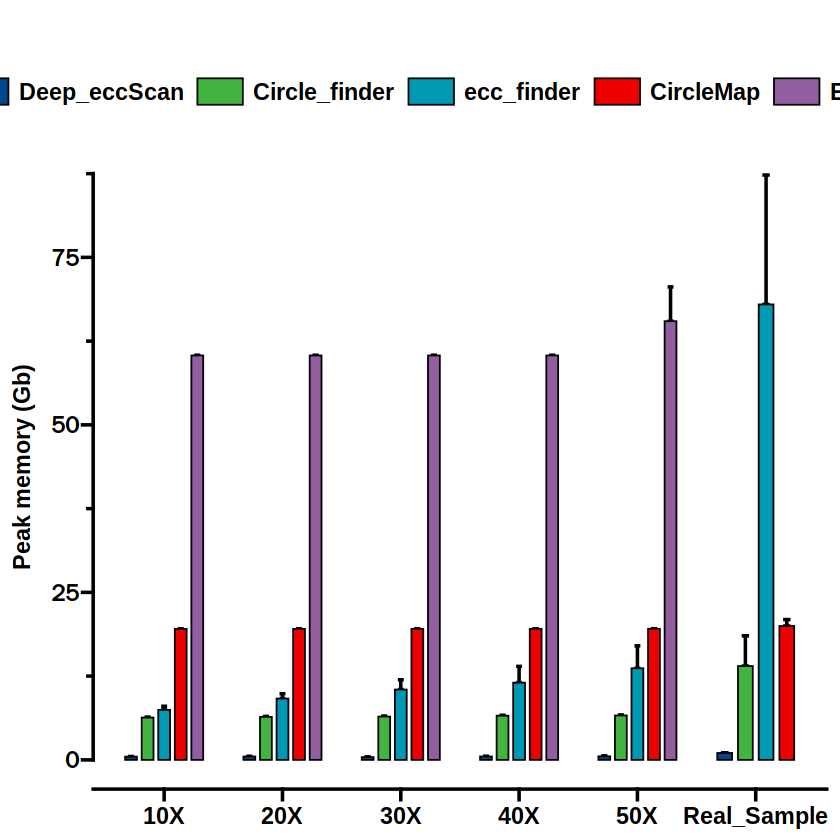

In [146]:

mem_bar = ggplot(data,aes(x=Depth, y=Peak_memory, fill = Tools))+ 
    stat_summary(geom='errorbar',fun.max = SEM_ebtop,fun.min=SEM_ebbottom,colour = "black", size=1, width = 0.25, position = position_dodge( .7)) +
    geom_bar(stat = "summary", fun="mean",colour= "black", size=1, width=0.5, position=position_dodge(.7), alpha=1) +
    scale_fill_manual(values=c('Deep_eccScan'='#00468BFF', 'CircleMap'='#ED0000FF', 'Circle_finder'='#42B540FF', 'ecc_finder'='#0099B4FF', 'ECCsplorer'='#925E9FFF')) +
    #scale_color_manual(values=c('Deep_eccScan'='#00468BFF', 'CircleMap'='#ED0000FF', 'Circle_finder'='#42B540FF', 'ecc_finder'='#0099B4FF', 'ECCsplorer'='#925E9FFF')) +
  labs(title = "",
       x = NULL, 
       y = "Peak memory (Gb)") +
   theme_classic()+mytheme+ theme_prism(base_size = 16) +guides(y = "prism_offset_minor") +
   ggplot2::theme(legend.position = "top") +ggplot2::theme(legend.text = element_text(size = 14,face = "bold",color = "black"))
mem_bar

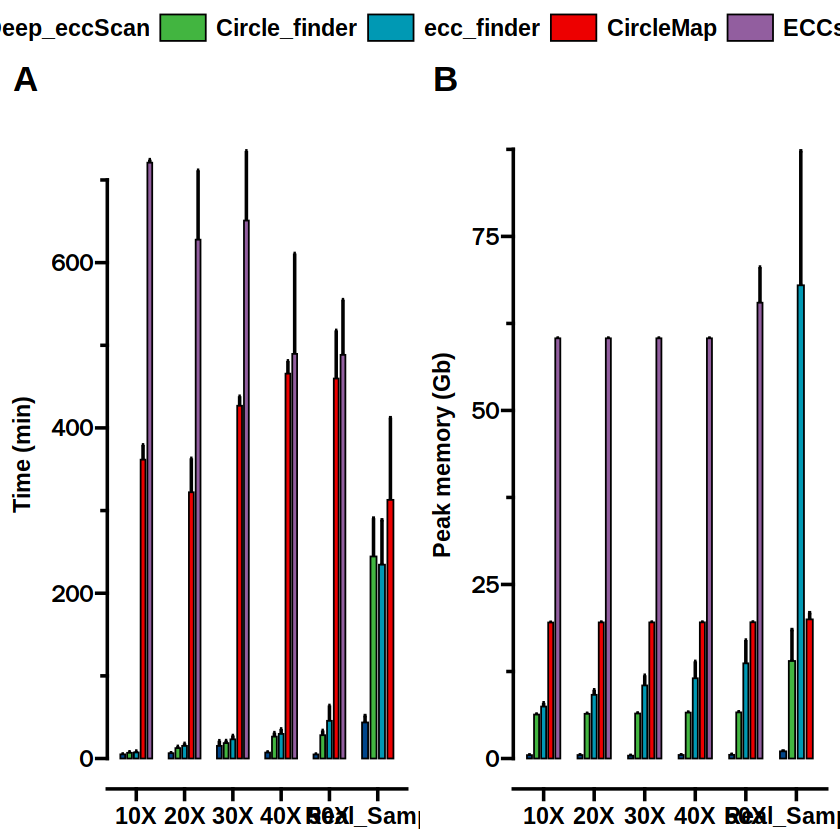

In [148]:
P = ggpubr::ggarrange(time_bar, mem_bar, tool_bar,
                      ncol = 2, nrow=2, font.label = list(size = 21, face = "bold", color = "black"),
                      labels="AUTO", common.legend = TRUE
                     )
P
ggsave(P,file=paste0("Figure5.pdf"),h=5,w=12)